# Problem Statement 1-->

Prepare a classification model using the Naive Bayes algorithm for the salary dataset. Train and test datasets are given separately. Use both for model building.

Business objective-->

Objective is to prepare classification model for salary dataset.

Constraints-->

The constraints includes imbalenced dataset, interpretability, etc

In [6]:
#import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [7]:
#load train and test dataset
train_data=pd.read_csv("F:/Data science/Assignments/diwali_assignment/SalaryData_Train.csv")
test_data=pd.read_csv("F:/Data science/Assignments/diwali_assignment/SalaryData_Test.csv")

In [4]:
data.head(5)

,age,workclass,education,educationno,maritalstatus,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native,Salary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
print(data.describe())

                age   educationno   capitalgain   capitalloss  hoursperweek
count  30161.000000  30161.000000  30161.000000  30161.000000  30161.000000
mean      38.438115     10.121316   1092.044064     88.302311     40.931269
std       13.134830      2.550037   7406.466611    404.121321     11.980182
min       17.000000      1.000000      0.000000      0.000000      1.000000
25%       28.000000      9.000000      0.000000      0.000000     40.000000
50%       37.000000     10.000000      0.000000      0.000000     40.000000
75%       47.000000     13.000000      0.000000      0.000000     45.000000
max       90.000000     16.000000  99999.000000   4356.000000     99.000000


In [8]:
#display dataset info
print("train dataset shape: ",train_data.shape)
print("test dataset shape: ",test_data.shape)

train dataset shape:  (30161, 14)
test dataset shape:  (15060, 14)


In [9]:
#combine train and test for consistent processing
combined_data = pd.concat([train_data, test_data], axis=0)

In [10]:
#encode categorical variables
label_encoders = {}  # To store LabelEncoders for inverse transformations if needed
for column in combined_data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    combined_data[column] = le.fit_transform(combined_data[column])
    label_encoders[column] = le

In [11]:
#split back into train and test datasets
train_processed = combined_data.iloc[:len(train_data), :]
test_processed = combined_data.iloc[len(train_data):, :]

In [12]:
#separate features and target variable
X_train = train_processed.drop(columns=['Salary'])
y_train = train_processed['Salary']

In [13]:
X_test = test_processed.drop(columns=['Salary'])
y_test = test_processed['Salary']

In [14]:
#build Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [15]:
#predictions
y_train_pred = nb_model.predict(X_train)
y_test_pred = nb_model.predict(X_test)

In [16]:
#evaluate the model
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Train Accuracy: 0.7953317197705646
Test Accuracy: 0.7946879150066402


In [18]:
#confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[10759   601]
 [ 2491  1209]]


In [19]:
#classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.87     11360
           1       0.67      0.33      0.44      3700

    accuracy                           0.79     15060
   macro avg       0.74      0.64      0.66     15060
weighted avg       0.78      0.79      0.77     15060



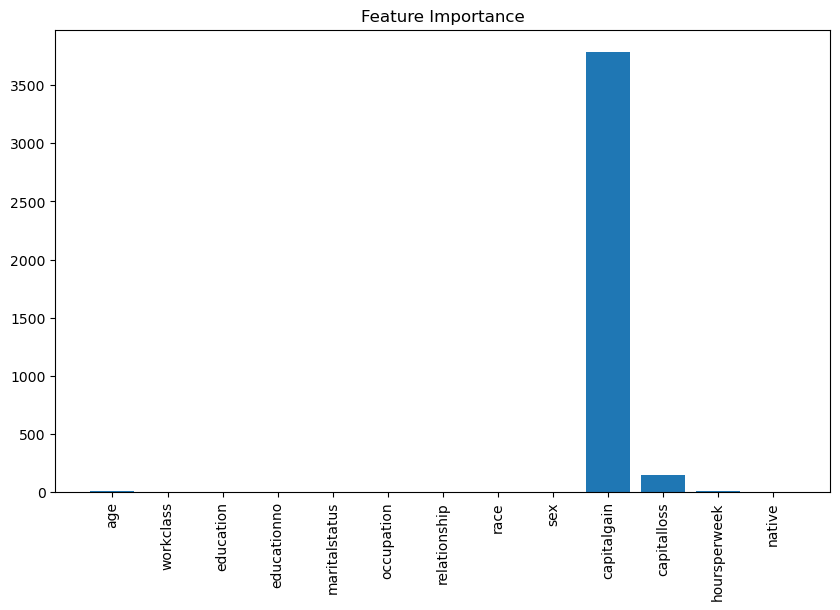

In [20]:
#visualization 
import matplotlib.pyplot as plt

feature_importance = np.abs(nb_model.theta_[1] - nb_model.theta_[0])  # Feature means difference
plt.figure(figsize=(10, 6))
plt.bar(X_train.columns, feature_importance)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

Important steps-->

1. Load train and test dataset

2. combine for preprocessing

3. label encoding

4. split back

5. model training

6. Predictions and Evaluation

7. feature importance (visualization)

# Problem Statement 2-->

This dataset contains information of users in a social network. This social network has several business clients which can post ads on it. One of the clients has a car company which has just launched a luxury SUV for a ridiculous price. Build a Bernoulli Naïve Bayes model using this dataset and classify which of the users of the social network are going to purchase this luxury SUV. 1 implies that there was a purchase and 0 implies there wasn’t a purchase.


Business objective-->

The objective is build model for classifying whether a user will purchase the luxury SUV

In [27]:
#import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, Binarizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
#Load dataset
data=pd.read_csv("F:/Data science/Assignments/diwali_assignment/NB_Car_Ad.csv")

In [23]:
#dataset information
data.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [29]:
#Preprocessing
#convert gender to the numeric (male: 1, female: 0)
data['Gender']=LabelEncoder().fit_transform(data['Gender'])

In [30]:
# Feature Scaling: Scale 'Age' and 'EstimatedSalary' for better performance
scaler = StandardScaler()
data[['Age', 'EstimatedSalary']] = scaler.fit_transform(data[['Age', 'EstimatedSalary']])

In [31]:
# Binarize the features (convert numerical features into binary)
binarizer = Binarizer(threshold=0.0)
data[['Age', 'EstimatedSalary']] = binarizer.fit_transform(data[['Age', 'EstimatedSalary']])

In [32]:
# Splitting data into features (X) and target (y)
X = data.drop(columns=['User ID', 'Purchased'])  # Exclude 'User ID' and target column
y = data['Purchased']

In [33]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
#model Building
bnb_model = BernoulliNB()
bnb_model.fit(X_train, y_train)

BernoulliNB()

In [35]:
#predictions
y_train_pred = bnb_model.predict(X_train)
y_test_pred = bnb_model.predict(X_test)

In [36]:
#evaluate the model
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Train Accuracy: 0.725
Test Accuracy: 0.725


In [37]:
#confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Confusion Matrix:
[[66  7]
 [26 21]]


In [38]:
#classification Report
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80        73
           1       0.75      0.45      0.56        47

    accuracy                           0.73       120
   macro avg       0.73      0.68      0.68       120
weighted avg       0.73      0.72      0.71       120



Expected output is train and test accuracy, confusion matrix and classification report.

# Problem Statement 3-->

In this case study, you have been given Twitter data collected from an anonymous twitter handle.With the help of a Naïve Bayes model, predict if a given tweet about a real disaster is real or fake.
1 = real tweet and 0 = fake tweet

Business objective-->

The objective includes to classify the tweets as real or fake disasters using a Naïve Bayes model, we need to preprocess the text data, remove unnecessary information, and train the model

In [43]:
#import required libraries
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
#load dataset
data=pd.read_csv("F:/Data science/Assignments/diwali_assignment/Disaster_tweets_NB.csv")

In [41]:
data.head(5)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [44]:
#check for missing values
print(data.isnull().sum())

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [45]:
#fill missing values in keyword and location with an empty string
data['keyword'] = data['keyword'].fillna("")
data['location'] = data['location'].fillna("")

In [46]:
#preprocess the text data
def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-zA-Z]", " ", text)  # Remove punctuation and numbers
    text = text.lower()  # Convert to lowercase
    text = text.split()  # Tokenize
    text = [word for word in text if len(word) > 2]  # Remove short words
    return " ".join(text)

In [47]:
# Apply the cleaning function to the 'text' column
data['cleaned_text'] = data['text'].apply(clean_text)

In [48]:
# Split the data into features (X) and target (y)
X = data['cleaned_text']
y = data['target']

In [49]:
#convert text into numerical format using Count Vectorizer
vectorizer = CountVectorizer(max_features=5000)  # Use top 5000 words
X_vectorized = vectorizer.fit_transform(X).toarray()

In [50]:
#split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

In [51]:
#Train a Multinomial Naïve Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [52]:
#Make predictions
y_pred = model.predict(X_test)

In [53]:
#evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 79.71%


In [54]:
#Print confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[755 119]
 [190 459]]


In [55]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       874
           1       0.79      0.71      0.75       649

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523



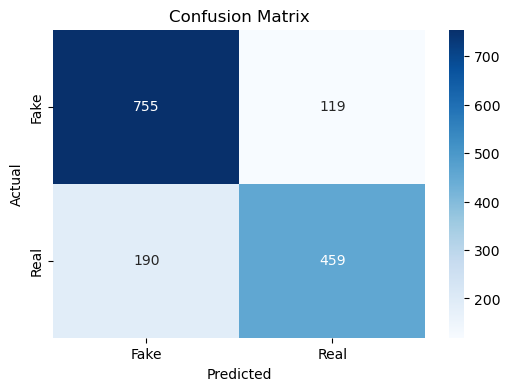

In [56]:
#visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:103: FutureWarning: Attribute `coef_` was deprecated in version 0.24 and will be removed in 1.1 (renaming of 0.26).
  warnings.warn(msg, category=FutureWarning)


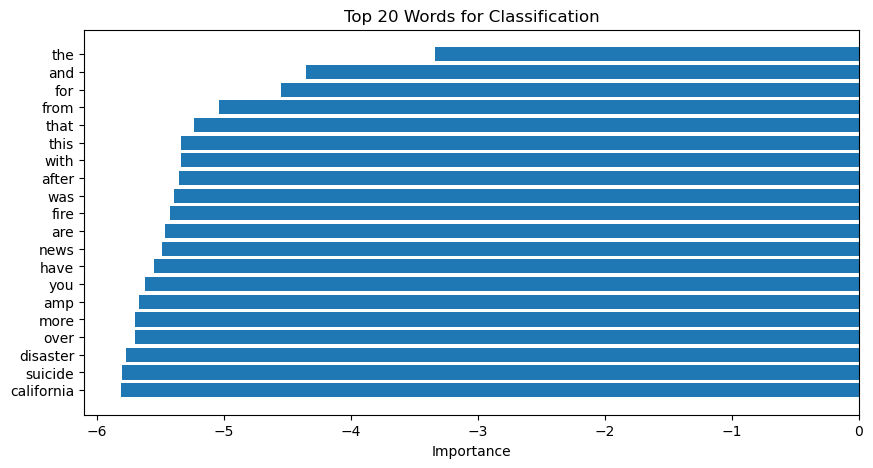

In [57]:
#plot the feature importance (top words)
feature_names = vectorizer.get_feature_names_out()
top_words = np.argsort(model.coef_[0])[-20:]  # Get top 20 words

plt.figure(figsize=(10, 5))
plt.barh(range(len(top_words)), model.coef_[0][top_words])
plt.yticks(range(len(top_words)), [feature_names[i] for i in top_words])
plt.xlabel("Importance")
plt.title("Top 20 Words for Classification")
plt.show()

Explanation-->

Accuracy: The percentage of correct predictions.
Confusion Matrix: Visual representation of true/false positives and negatives.
Top Words: Displays the most influential words for classification.